# 05 — Entraînement et évaluation des modèles de classification des émissions de CO₂

## Objectif général

Ce notebook construit, compare, optimise et sélectionne un modèle de
**classification multiclasse des émissions de CO₂** à partir des données
prétraitées produites par le pipeline MLOps.

La cible continue `co2_wltp_g_km` est transformée en classes d'émissions
interprétables **A à G** à partir de seuils métier fixes.

Le protocole suit les principes suivants :

- utiliser les artefacts prétraités produits par l'étape précédente ;
- travailler avec la structure courante des variables explicatives ;
- vérifier explicitement que `manufacturer_make` n'est plus utilisée ;
- construire les jeux de développement exclusivement à partir du Train FULL ;
- conserver le Test final isolé pendant l'entraînement, la comparaison et le tuning ;
- utiliser le **F1-macro** comme métrique principale de sélection ;
- ne pas inscrire de résultats expérimentaux en dur dans les cellules Markdown ;
- générer les résultats et leur interprétation dynamiquement dans les cellules de code ;
- préparer les métadonnées nécessaires à l'entraînement industrialisé du modèle final.

Le notebook ne réalise pas l'entraînement final sur l'intégralité du Train FULL.
Cette opération reste confiée au script Python industrialisé et au stage DVC
`train_classification_model`.

## 1. Chargement et validation des données prétraitées

Cette étape charge les quatre artefacts produits par le preprocessing :

- `X_train_processed.parquet` ;
- `X_test_processed.parquet` ;
- `y_train.parquet` ;
- `y_test.parquet`.

Le notebook vérifie immédiatement la cohérence des dimensions, l'absence de
valeurs manquantes, le caractère numérique des variables explicatives et
l'exclusion de `manufacturer_make`.

Le jeu Test final est chargé afin de vérifier sa structure, mais ses valeurs
cibles ne sont pas utilisées pour sélectionner les modèles.

In [1]:
# =====================================================================
# 1 - Chargement et validation des données prétraitées
# =====================================================================

from pathlib import Path
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)


# ---------------------------------------------------------------------
# Configuration générale
# ---------------------------------------------------------------------

RANDOM_STATE = 42
DEVELOPMENT_SAMPLE_SIZE = 500_000
VALIDATION_SIZE = 0.20

TARGET_COLUMN = "co2_wltp_g_km"


# ---------------------------------------------------------------------
# Recherche robuste de la racine du projet
# ---------------------------------------------------------------------

def find_project_root(start_path: Path) -> Path:
    """Retourne le premier parent contenant pyproject.toml."""

    start_path = start_path.resolve()

    for candidate in [start_path, *start_path.parents]:
        if (candidate / "pyproject.toml").is_file():
            return candidate

    raise FileNotFoundError(
        "Impossible de localiser la racine du projet : "
        "pyproject.toml introuvable."
    )


project_root = find_project_root(Path.cwd())

processed_dir = project_root / "data" / "processed"
reports_dir = project_root / "reports" / "tables"
metadata_dir = project_root / "models" / "metadata"

reports_dir.mkdir(parents=True, exist_ok=True)
metadata_dir.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------------------
# Chemins des artefacts prétraités
# ---------------------------------------------------------------------

x_train_path = processed_dir / "X_train_processed.parquet"
x_test_path = processed_dir / "X_test_processed.parquet"
y_train_path = processed_dir / "y_train.parquet"
y_test_path = processed_dir / "y_test.parquet"

required_paths = [
    x_train_path,
    x_test_path,
    y_train_path,
    y_test_path,
]

missing_paths = [
    path
    for path in required_paths
    if not path.is_file()
]

if missing_paths:
    raise FileNotFoundError(
        "Artefact(s) prétraité(s) manquant(s) : "
        + ", ".join(str(path) for path in missing_paths)
    )


# ---------------------------------------------------------------------
# Chargement
# ---------------------------------------------------------------------

print("=" * 110)
print("CHARGEMENT DES DONNÉES PRÉTRAITÉES")
print("=" * 110)

print(
    "\nContexte :"
    "\nLe notebook utilise les artefacts produits par le preprocessing "
    "Train / Test."
)

print(
    "\nObjectif :"
    "\nVérifier la structure des données avant toute construction "
    "de la cible de classification."
)

X_train = pd.read_parquet(x_train_path)
X_test = pd.read_parquet(x_test_path)

y_train_df = pd.read_parquet(y_train_path)
y_test_df = pd.read_parquet(y_test_path)

if TARGET_COLUMN not in y_train_df.columns:
    raise ValueError(
        f"La cible '{TARGET_COLUMN}' est absente de y_train.parquet."
    )

if TARGET_COLUMN not in y_test_df.columns:
    raise ValueError(
        f"La cible '{TARGET_COLUMN}' est absente de y_test.parquet."
    )

y_train = y_train_df[TARGET_COLUMN]
y_test = y_test_df[TARGET_COLUMN]


# ---------------------------------------------------------------------
# Validation structurelle
# ---------------------------------------------------------------------

checks = {
    "Cohérence X_train / y_train":
        len(X_train) == len(y_train),

    "Cohérence X_test / y_test":
        len(X_test) == len(y_test),

    "Colonnes Train / Test identiques":
        X_train.columns.tolist() == X_test.columns.tolist(),

    "Cible absente de X_train":
        TARGET_COLUMN not in X_train.columns,

    "Cible absente de X_test":
        TARGET_COLUMN not in X_test.columns,

    "Aucun NaN dans X_train":
        not X_train.isna().any().any(),

    "Aucun NaN dans X_test":
        not X_test.isna().any().any(),

    "Aucun NaN dans y_train":
        not y_train.isna().any(),

    "Aucun NaN dans y_test":
        not y_test.isna().any(),

    "X_train entièrement numérique":
        X_train.select_dtypes(exclude="number").shape[1] == 0,

    "X_test entièrement numérique":
        X_test.select_dtypes(exclude="number").shape[1] == 0,

    "manufacturer_make exclue":
        all(
            "manufacturer_make" not in column.lower()
            for column in X_train.columns
        ),
}

failed_checks = [
    name
    for name, result in checks.items()
    if not result
]



# ---------------------------------------------------------------------
# Rapport
# ---------------------------------------------------------------------

classification_data_report_df = pd.DataFrame(
    [
        {
            "jeu_de_donnees": "X_train",
            "observations": len(X_train),
            "variables": X_train.shape[1],
            "role": "Variables explicatives d'entraînement",
        },
        {
            "jeu_de_donnees": "y_train",
            "observations": len(y_train),
            "variables": 1,
            "role": (
                "Cible d'entraînement utilisée pour "
                "définir les classes"
            ),
        },
        {
            "jeu_de_donnees": "X_test",
            "observations": len(X_test),
            "variables": X_test.shape[1],
            "role": "Variables explicatives du Test final",
        },
        {
            "jeu_de_donnees": "y_test",
            "observations": len(y_test),
            "variables": 1,
            "role": "Cible réservée au Test final",
        },
    ]
)

display(
    classification_data_report_df
)


print("\nCHARGEMENT DES DONNÉES DE CLASSIFICATION")
print("=" * 70)

print(
    f"\nTrain : "
    f"{len(X_train):,} observations × "
    f"{X_train.shape[1]} variables"
)

print(
    f"Test  : "
    f"{len(X_test):,} observations × "
    f"{X_test.shape[1]} variables"
)

print(
    "\n✅ Données prétraitées chargées et cohérentes."
)

print(
    "✅ y_train conserve actuellement les valeurs "
    "initiales de co2_wltp_g_km."
)

print(
    "✅ Aucune classe d'émission n'a encore été créée."
)

print(
    "✅ y_test reste exclu de la définition "
    "des seuils de discrétisation."
)

print(
    "✅ manufacturer_make est absente des variables explicatives."
)

print(
    f"✅ Structure actuelle validée : "
    f"{X_train.shape[1]} variables explicatives."
)


CHARGEMENT DES DONNÉES PRÉTRAITÉES

Contexte :
Le notebook utilise les artefacts produits par le preprocessing Train / Test.

Objectif :
Vérifier la structure des données avant toute construction de la cible de classification.


,jeu_de_donnees,observations,variables,role
0,X_train,8606547,35,Variables explicatives d'entraînement
1,y_train,8606547,1,Cible d'entraînement utilisée pour définir les...
2,X_test,2151637,35,Variables explicatives du Test final
3,y_test,2151637,1,Cible réservée au Test final



CHARGEMENT DES DONNÉES DE CLASSIFICATION

Train : 8,606,547 observations × 35 variables
Test  : 2,151,637 observations × 35 variables

✅ Données prétraitées chargées et cohérentes.
✅ y_train conserve actuellement les valeurs initiales de co2_wltp_g_km.
✅ Aucune classe d'émission n'a encore été créée.
✅ y_test reste exclu de la définition des seuils de discrétisation.
✅ manufacturer_make est absente des variables explicatives.
✅ Structure actuelle validée : 35 variables explicatives.


## 2. Analyse statistique de la cible `co2_wltp_g_km`

L'étude de la cible est réalisée **uniquement sur `y_train`**.

L'objectif est de caractériser la distribution des émissions avant leur
transformation en classes. Cette analyse permet notamment d'identifier
l'étendue des valeurs, la dispersion et la présence éventuelle de valeurs
extrêmes.

`y_test` n'intervient pas dans cette analyse.

### 2.1 — Statistiques descriptives de la cible

Les statistiques descriptives sont calculées dynamiquement sur `y_train`.
Aucune valeur issue d'une exécution précédente n'est inscrite en dur.

In [2]:
# =====================================================================
# 2.1 - Statistiques descriptives de la cible
# =====================================================================

print("=" * 110)
print("STATISTIQUES DESCRIPTIVES DE co2_wltp_g_km")
print("=" * 110)

print(
    "\nContexte :"
    "\nL'analyse porte exclusivement sur la cible continue du Train FULL."
)

target_statistics = y_train.describe(
    percentiles=[
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99,
    ]
).to_frame("Valeur")

display(target_statistics)

print(
    f"\nObservations analysées : {len(y_train):,}"
)

print(
    f"Valeurs distinctes      : {y_train.nunique():,}"
)

print(
    f"Valeurs manquantes      : {y_train.isna().sum():,}"
)

print(
    "\n✅ Les statistiques ont été calculées exclusivement sur y_train."
)

STATISTIQUES DESCRIPTIVES DE co2_wltp_g_km

Contexte :
L'analyse porte exclusivement sur la cible continue du Train FULL.


,Valeur
count,8.606547e+06
mean,1.068751e+02
std,5.794969e+01
min,0.000000e+00
1%,0.000000e+00
5%,0.000000e+00
25%,1.010000e+02
50%,1.230000e+02
75%,1.370000e+02
95%,1.810000e+02



Observations analysées : 8,606,547
Valeurs distinctes      : 415
Valeurs manquantes      : 0

✅ Les statistiques ont été calculées exclusivement sur y_train.


### 2.2 — Analyse de la distribution des émissions de CO₂

Cette étape complète les statistiques descriptives par des indicateurs de
forme de distribution et par l'étude des quantiles.

Les résultats restent calculés dynamiquement sur le Train.

In [3]:
# =====================================================================
# 2.2 - Analyse de la distribution de la cible
# =====================================================================

print("=" * 110)
print("ANALYSE DE LA DISTRIBUTION DE co2_wltp_g_km")
print("=" * 110)

distribution_summary_df = pd.DataFrame(
    {
        "indicateur": [
            "Minimum",
            "Q1",
            "Médiane",
            "Moyenne",
            "Q3",
            "Maximum",
            "Écart-type",
            "Asymétrie",
        ],
        "valeur": [
            y_train.min(),
            y_train.quantile(0.25),
            y_train.median(),
            y_train.mean(),
            y_train.quantile(0.75),
            y_train.max(),
            y_train.std(),
            y_train.skew(),
        ],
    }
)

display(distribution_summary_df.round(4))

print(
    "\nLecture :"
    "\nCes indicateurs servent à caractériser la cible avant "
    "la définition des classes de classification."
)

print(
    "\n✅ Aucun calcul n'a été réalisé à partir de y_test."
)

ANALYSE DE LA DISTRIBUTION DE co2_wltp_g_km


,indicateur,valeur
0,Minimum,0.0000
1,Q1,101.0000
2,Médiane,123.0000
3,Moyenne,106.8751
4,Q3,137.0000
5,Maximum,543.0000
6,Écart-type,57.9497
7,Asymétrie,-0.5317



Lecture :
Ces indicateurs servent à caractériser la cible avant la définition des classes de classification.

✅ Aucun calcul n'a été réalisé à partir de y_test.


### 2.3 — Visualisation de la distribution de la cible

Les graphiques permettent de compléter l'analyse statistique en visualisant la
concentration des observations et l'étendue des émissions.

La visualisation porte uniquement sur `y_train`.

VISUALISATION DE LA DISTRIBUTION DE co2_wltp_g_km

Observations visualisées : 8,606,547


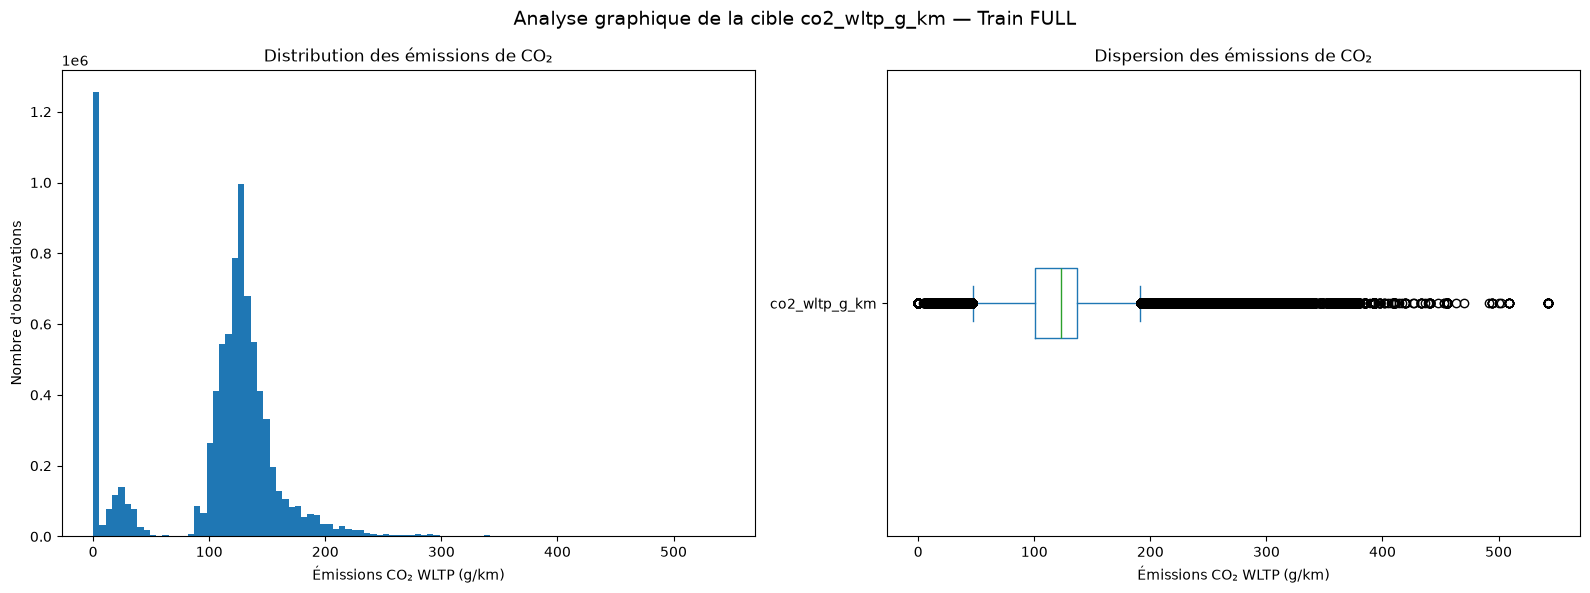


✅ Histogramme et boxplot générés exclusivement à partir de y_train.
✅ Le Test final reste exclu de l'analyse graphique.


In [4]:

# =====================================================================
# 2.3 - Visualisation de la distribution de y_train
# =====================================================================

print("=" * 110)
print("VISUALISATION DE LA DISTRIBUTION DE co2_wltp_g_km")
print("=" * 110)

print(
    f"\nObservations visualisées : {len(y_train):,}"
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6),
)


# ---------------------------------------------------------------------
# Histogramme
# ---------------------------------------------------------------------

y_train.plot.hist(
    bins=100,
    ax=axes[0],
)

axes[0].set_title(
    "Distribution des émissions de CO₂"
)

axes[0].set_xlabel(
    "Émissions CO₂ WLTP (g/km)"
)

axes[0].set_ylabel(
    "Nombre d'observations"
)


# ---------------------------------------------------------------------
# Boxplot
# ---------------------------------------------------------------------

y_train.plot.box(
    ax=axes[1],
    vert=False,
)

axes[1].set_title(
    "Dispersion des émissions de CO₂"
)

axes[1].set_xlabel(
    "Émissions CO₂ WLTP (g/km)"
)

axes[1].set_ylabel("")


# ---------------------------------------------------------------------
# Titre général
# ---------------------------------------------------------------------

fig.suptitle(
    "Analyse graphique de la cible co2_wltp_g_km — Train FULL",
    fontsize=14,
)

plt.tight_layout()
plt.show()


print(
    "\n✅ Histogramme et boxplot générés exclusivement à partir de y_train."
)

print(
    "✅ Le Test final reste exclu de l'analyse graphique."
)


## 3. Étude des stratégies de discrétisation de la cible

La transformation de `co2_wltp_g_km` en variable de classification nécessite
de définir des intervalles représentant plusieurs niveaux d'émissions.

Cette étude est conduite exclusivement sur `y_train`.

Plusieurs stratégies sont examinées afin de distinguer :

- l'équilibre statistique des classes ;
- leur granularité ;
- leur interprétabilité ;
- leur cohérence métier.

Le jeu Test final reste exclu de la définition et de l'étude des seuils.

### 3.1 — Construction et comparaison de stratégies candidates

Trois approches sont comparées sur une granularité commune de cinq classes :

1. intervalles réguliers ;
2. quantiles ;
3. seuils explicites candidats.

Ces stratégies constituent uniquement un diagnostic exploratoire.

In [5]:
# =====================================================================
# 3.1 - Comparaison de stratégies candidates de discrétisation
# =====================================================================

N_CLASSES_DIAGNOSTIC = 5

classes_uniform, bins_uniform = pd.cut(
    y_train,
    bins=N_CLASSES_DIAGNOSTIC,
    retbins=True,
    include_lowest=True,
)

classes_quantile, bins_quantile = pd.qcut(
    y_train,
    q=N_CLASSES_DIAGNOSTIC,
    retbins=True,
    duplicates="drop",
)

bins_explicit = [
    -float("inf"),
    50,
    100,
    160,
    200,
    float("inf"),
]

classes_explicit = pd.cut(
    y_train,
    bins=bins_explicit,
    include_lowest=True,
)


def summarize_discretization(
    classes: pd.Series,
    strategy: str,
) -> pd.DataFrame:
    """Synthétise une discrétisation sans réimplémenter son calcul."""

    summary = (
        classes
        .value_counts(sort=False)
        .rename("Nombre d'observations")
        .to_frame()
    )

    summary["Proportion (%)"] = (
        summary["Nombre d'observations"]
        .div(len(y_train))
        .mul(100)
    )

    summary.insert(
        0,
        "Stratégie de discrétisation",
        strategy,
    )

    summary.index.name = "Intervalle CO₂ WLTP (g/km)"

    return summary.reset_index()


discretization_comparison_df = pd.concat(
    [
        summarize_discretization(
            classes_uniform,
            "Intervalles réguliers",
        ),
        summarize_discretization(
            classes_quantile,
            "Quantiles",
        ),
        summarize_discretization(
            classes_explicit,
            "Seuils explicites candidats",
        ),
    ],
    ignore_index=True,
)

discretization_bounds_df = pd.DataFrame(
    {
        "stratégie": [
            "Intervalles réguliers",
            "Quantiles",
            "Seuils explicites candidats",
        ],
        "nombre_classes": [
            len(bins_uniform) - 1,
            len(bins_quantile) - 1,
            len(bins_explicit) - 1,
        ],
        "bornes_g_co2_km": [
            bins_uniform.round(2).tolist(),
            bins_quantile.round(2).tolist(),
            bins_explicit,
        ],
    }
)

print("=" * 110)
print("COMPARAISON DES STRATÉGIES DE DISCRÉTISATION")
print("=" * 110)

display(
    discretization_comparison_df.round(
        {"Proportion (%)": 2}
    )
)

print("\nBORNES OBTENUES")
display(discretization_bounds_df)

print(
    "\n✅ Toutes les stratégies ont été construites exclusivement sur y_train."
)

COMPARAISON DES STRATÉGIES DE DISCRÉTISATION


,Intervalle CO₂ WLTP (g/km),Stratégie de discrétisation,Nombre d'observations,Proportion (%)
0,"(-0.544, 108.6]",Intervalles réguliers,2687515,31.23
1,"(108.6, 217.2]",Intervalles réguliers,5776864,67.12
2,"(217.2, 325.8]",Intervalles réguliers,134252,1.56
3,"(325.8, 434.4]",Intervalles réguliers,7784,0.09
4,"(434.4, 543.0]",Intervalles réguliers,132,0.00
5,"(-0.001, 33.0]",Quantiles,1738499,20.20
6,"(33.0, 117.0]",Quantiles,1744952,20.27
7,"(117.0, 128.0]",Quantiles,1770000,20.57
8,"(128.0, 142.0]",Quantiles,1642507,19.08
9,"(142.0, 543.0]",Quantiles,1710589,19.88



BORNES OBTENUES


,stratégie,nombre_classes,bornes_g_co2_km
0,Intervalles réguliers,5,"[-0.54, 108.6, 217.2, 325.8, 434.4, 543.0]"
1,Quantiles,5,"[0.0, 33.0, 117.0, 128.0, 142.0, 543.0]"
2,Seuils explicites candidats,5,"[-inf, 50, 100, 160, 200, inf]"



✅ Toutes les stratégies ont été construites exclusivement sur y_train.


### 3.2 — Étude du nombre de classes

Le nombre de classes influence directement la granularité du problème.

Une discrétisation par quantiles est utilisée ici uniquement comme outil de
diagnostic statistique pour comparer différentes granularités. Les seuils
définitifs ne sont pas déterminés par cette étape.

In [6]:
# =====================================================================
# 3.2 - Étude du nombre de classes
# =====================================================================

candidate_class_counts = [3, 4, 5, 6, 7]

class_count_results = []

for requested_classes in candidate_class_counts:

    classes, bins = pd.qcut(
        y_train,
        q=requested_classes,
        retbins=True,
        duplicates="drop",
    )

    proportions = (
        classes
        .value_counts(normalize=True, sort=False)
        .mul(100)
    )

    class_count_results.append(
        {
            "classes_demandées": requested_classes,
            "classes_obtenues": len(bins) - 1,
            "proportion_min_%": proportions.min(),
            "proportion_max_%": proportions.max(),
            "écart_max_min_points": (
                proportions.max() - proportions.min()
            ),
            "bornes_g_co2_km": bins.round(2).tolist(),
        }
    )

class_count_summary_df = pd.DataFrame(
    class_count_results
)

print("=" * 110)
print("ÉTUDE DU NOMBRE DE CLASSES")
print("=" * 110)

print(
    "\nMéthode : quantiles utilisés comme diagnostic statistique."
)

display(
    class_count_summary_df.round(
        {
            "proportion_min_%": 2,
            "proportion_max_%": 2,
            "écart_max_min_points": 2,
        }
    )
)

print(
    "\n✅ Le jeu Test final reste totalement exclu de cette étude."
)

ÉTUDE DU NOMBRE DE CLASSES

Méthode : quantiles utilisés comme diagnostic statistique.


,classes_demandées,classes_obtenues,proportion_min_%,proportion_max_%,écart_max_min_points,bornes_g_co2_km
0,3,3,33.30,33.39,0.09,"[0.0, 110.0, 131.0, 543.0]"
1,4,4,23.37,26.52,3.15,"[0.0, 101.0, 123.0, 137.0, 543.0]"
2,5,5,19.08,20.57,1.48,"[0.0, 33.0, 117.0, 128.0, 142.0, 543.0]"
3,6,6,14.90,18.41,3.51,"[0.0, 19.0, 110.0, 123.0, 131.0, 146.0, 543.0]"
4,7,6,13.06,29.02,15.95,"[0.0, 106.0, 119.0, 126.0, 134.0, 149.0, 543.0]"



✅ Le jeu Test final reste totalement exclu de cette étude.


### 3.3 — Analyse multicritère du nombre de classes

L'équilibre statistique ne suffit pas à déterminer la classification finale.

Le choix doit également considérer :

- la granularité ;
- la séparation des niveaux d'émission ;
- l'interprétabilité des intervalles ;
- la complexité du problème ;
- la stabilité métier des seuils.

L'étape précédente constitue donc un diagnostic et non une sélection
automatique du nombre de classes.

### 3.4 — Étude de scénarios de seuils interprétables

Plusieurs scénarios explicites sont étudiés sur `y_train`.

Ils permettent d'observer comment différents choix de seuils influencent les
effectifs et l'équilibre des classes. Ces scénarios restent des hypothèses de
travail et ne remplacent pas le référentiel métier retenu ensuite.

In [7]:
# =====================================================================
# 3.4 - Étude de scénarios de seuils interprétables
# =====================================================================

candidate_scenarios = {
    "Scénario A": [
        -float("inf"),
        50,
        100,
        150,
        200,
        float("inf"),
    ],
    "Scénario B": [
        -float("inf"),
        75,
        110,
        140,
        180,
        float("inf"),
    ],
    "Scénario C": [
        -float("inf"),
        50,
        110,
        140,
        180,
        float("inf"),
    ],
}

scenario_summary = []

for scenario_name, bins in candidate_scenarios.items():

    classes = pd.cut(
        y_train,
        bins=bins,
        include_lowest=True,
    )

    proportions = (
        classes
        .value_counts(normalize=True, sort=False)
        .mul(100)
    )

    scenario_summary.append(
        {
            "scénario": scenario_name,
            "nombre_classes": len(bins) - 1,
            "proportion_min_%": proportions.min(),
            "proportion_max_%": proportions.max(),
            "écart_max_min_points": (
                proportions.max() - proportions.min()
            ),
            "bornes_g_co2_km": bins,
        }
    )

scenario_summary_df = pd.DataFrame(
    scenario_summary
)

print("=" * 110)
print("SCÉNARIOS DE SEUILS INTERPRÉTABLES")
print("=" * 110)

display(
    scenario_summary_df.round(
        {
            "proportion_min_%": 2,
            "proportion_max_%": 2,
            "écart_max_min_points": 2,
        }
    )
)

print(
    "\n✅ Les scénarios sont analysés uniquement sur y_train."
)

SCÉNARIOS DE SEUILS INTERPRÉTABLES


,scénario,nombre_classes,proportion_min_%,proportion_max_%,écart_max_min_points,bornes_g_co2_km
0,Scénario A,5,2.63,62.20,59.57,"[-inf, 50, 100, 150, 200, inf]"
1,Scénario B,5,5.03,44.55,39.52,"[-inf, 75, 110, 140, 180, inf]"
2,Scénario C,5,5.03,44.55,39.52,"[-inf, 50, 110, 140, 180, inf]"



✅ Les scénarios sont analysés uniquement sur y_train.


### 3.5 — Application du référentiel ADEME à `y_train`

La cible est maintenant discrétisée selon les classes A à G retenues dans le
projet.

Les seuils sont fixes et appliqués uniquement à `y_train` à cette étape.

Cette analyse permet de mesurer la représentation des différentes classes avant
la modélisation.

In [8]:
# =====================================================================
# 3.5 - Application du référentiel ADEME à y_train
# =====================================================================

ADEME_BINS = [
    -float("inf"),
    100,
    120,
    140,
    160,
    200,
    250,
    float("inf"),
]

ADEME_LABELS = [
    "A",
    "B",
    "C",
    "D",
    "E",
    "F",
    "G",
]

CLASS_INTERVALS = {
    "A": "≤ 100",
    "B": "]100 ; 120]",
    "C": "]120 ; 140]",
    "D": "]140 ; 160]",
    "E": "]160 ; 200]",
    "F": "]200 ; 250]",
    "G": "> 250",
}

CLASS_BUSINESS_LABELS = {
    "A": "Très faibles émissions",
    "B": "Faibles émissions",
    "C": "Émissions modérées",
    "D": "Émissions intermédiaires",
    "E": "Émissions élevées",
    "F": "Très fortes émissions",
    "G": "Émissions extrêmement élevées",
}


# ---------------------------------------------------------------------
# Création de la cible de classification Train
# ---------------------------------------------------------------------

y_train_class = pd.cut(
    y_train,
    bins=ADEME_BINS,
    labels=ADEME_LABELS,
    include_lowest=True,
)

if y_train_class.isna().any():
    raise ValueError(
        "Certaines observations de y_train ne sont pas classées."
    )


# ---------------------------------------------------------------------
# Distribution
# ---------------------------------------------------------------------

ademe_distribution_df = pd.DataFrame(
    {
        "Classe ADEME": ADEME_LABELS,
        "Intervalle CO₂ WLTP (g/km)": [
            CLASS_INTERVALS[label]
            for label in ADEME_LABELS
        ],
        "Niveau d'émission": [
            CLASS_BUSINESS_LABELS[label]
            for label in ADEME_LABELS
        ],
        "Nombre d'observations": [
            int((y_train_class == label).sum())
            for label in ADEME_LABELS
        ],
        "Proportion (%)": [
            float((y_train_class == label).mean() * 100)
            for label in ADEME_LABELS
        ],
    }
)

print("=" * 110)
print("RÉPARTITION DE y_train SELON LES CLASSES ADEME")
print("=" * 110)

display(
    ademe_distribution_df.round(
        {"Proportion (%)": 2}
    )
)

print(
    f"\nObservations classées : {y_train_class.notna().sum():,}"
)

print(
    f"Observations non classées : {y_train_class.isna().sum():,}"
)

print(
    "\n✅ La cible de classification Train est valide."
)

print(
    "✅ y_test n'a pas encore été discrétisé ni analysé."
)

RÉPARTITION DE y_train SELON LES CLASSES ADEME


,Classe ADEME,Intervalle CO₂ WLTP (g/km),Niveau d'émission,Nombre d'observations,Proportion (%)
0,A,≤ 100,Très faibles émissions,2100183,24.40
1,B,]100 ; 120],Faibles émissions,1925350,22.37
2,C,]120 ; 140],Émissions modérées,2682493,31.17
3,D,]140 ; 160],Émissions intermédiaires,1138641,13.23
4,E,]160 ; 200],Émissions élevées,533556,6.20
5,F,]200 ; 250],Très fortes émissions,165326,1.92
6,G,> 250,Émissions extrêmement élevées,60998,0.71



Observations classées : 8,606,547
Observations non classées : 0

✅ La cible de classification Train est valide.
✅ y_test n'a pas encore été discrétisé ni analysé.


### 3.6 — Validation de la cible de classification Train

La cible `y_train_class` devient la cible utilisée pour l'apprentissage et la
sélection des modèles.

Le Test final reste volontairement sans cible de classification à ce stade.
`y_test_class` ne sera créé qu'après sélection définitive du candidat, à partir
des mêmes seuils fixes.

Cette organisation renforce l'isolation du Test final.

In [9]:
# =====================================================================
# 3.6 - Validation de la cible de classification Train
# =====================================================================

class_counts = (
    y_train_class
    .value_counts(sort=False)
)

class_proportions = (
    y_train_class
    .value_counts(normalize=True, sort=False)
    .mul(100)
)

target_validation_df = pd.DataFrame(
    {
        "classe": ADEME_LABELS,
        "observations": [
            int(class_counts.get(label, 0))
            for label in ADEME_LABELS
        ],
        "proportion_%": [
            float(class_proportions.get(label, 0.0))
            for label in ADEME_LABELS
        ],
    }
)

print("=" * 110)
print("VALIDATION DE LA CIBLE DE CLASSIFICATION TRAIN")
print("=" * 110)

display(
    target_validation_df.round(
        {"proportion_%": 2}
    )
)

print(
    f"\nNombre de classes : {y_train_class.nunique()}"
)

print(
    f"Nombre d'observations : {len(y_train_class):,}"
)

assert len(y_train_class) == len(X_train)
assert y_train_class.isna().sum() == 0
assert set(y_train_class.astype(str).unique()) == set(ADEME_LABELS)

print(
    "\n✅ Correspondance X_train / y_train_class conservée."
)

print(
    "✅ Les 7 classes A à G sont présentes."
)

print(
    "✅ Le Test final reste totalement exclu de la sélection."
)

VALIDATION DE LA CIBLE DE CLASSIFICATION TRAIN


,classe,observations,proportion_%
0,A,2100183,24.40
1,B,1925350,22.37
2,C,2682493,31.17
3,D,1138641,13.23
4,E,533556,6.20
5,F,165326,1.92
6,G,60998,0.71



Nombre de classes : 7
Nombre d'observations : 8,606,547

✅ Correspondance X_train / y_train_class conservée.
✅ Les 7 classes A à G sont présentes.
✅ Le Test final reste totalement exclu de la sélection.


## 4. Modélisation de classification

La modélisation utilise la cible `y_train_class` comportant sept classes A à G.

La stratégie reproduit la logique méthodologique retenue pour le notebook de
régression :

1. construire un sous-échantillon de développement exclusivement depuis le
   Train FULL ;
2. séparer ce sous-échantillon en Train développement et Validation
   développement ;
3. comparer les modèles sur exactement le même jeu de validation ;
4. optimiser le meilleur candidat sans utiliser le Test final ;
5. sélectionner la configuration finale ;
6. utiliser le Test final une seule fois pour l'évaluation finale du candidat.

### 4.1 — Métriques d'évaluation

La cible est déséquilibrée entre les classes. L'Accuracy seule peut donc
favoriser les classes majoritaires.

La métrique principale retenue est le **F1-macro**, qui accorde le même poids à
chaque classe.

Les métriques complémentaires sont :

- Accuracy ;
- Balanced Accuracy ;
- F1-weighted.

L'analyse est complétée par les rapports par classe et les matrices de
confusion.

### 4.2 — Modèles candidats et stratégie de comparaison

Trois familles de modèles sont comparées :

1. **Logistic Regression** comme baseline linéaire ;
2. **Random Forest Classifier** pour les relations non linéaires et interactions ;
3. **HistGradientBoosting Classifier** comme modèle de boosting adapté aux
   données tabulaires.

Les trois modèles sont entraînés sur le même Train développement et évalués sur
la même Validation développement.

### 4.3 — Préparation des jeux de développement

Un sous-échantillon stratifié est extrait exclusivement du Train FULL.

Il est ensuite séparé en deux ensembles disjoints :

- Train développement pour l'apprentissage ;
- Validation développement pour la comparaison et la sélection.

Le Test final reste totalement isolé.

In [10]:
# =====================================================================
# 4.3 - Préparation des jeux de développement
# =====================================================================

print("=" * 110)
print("PRÉPARATION DES JEUX DE DÉVELOPPEMENT")
print("=" * 110)

print(
    "\nContexte :"
    "\nLe preprocessing précédent a produit un Train FULL et un Test final."
)

print(
    "\nObjectif :"
    "\nCréer exclusivement à partir du Train FULL un sous-échantillon "
    "stratifié de développement, puis le séparer en Train et Validation."
)

if DEVELOPMENT_SAMPLE_SIZE > len(X_train):
    raise ValueError(
        "DEVELOPMENT_SAMPLE_SIZE dépasse le nombre d'observations "
        "disponibles dans X_train."
    )


# ---------------------------------------------------------------------
# 1. Extraction stratifiée du sous-échantillon
# ---------------------------------------------------------------------

(
    X_development,
    _,
    y_development,
    _,
) = train_test_split(
    X_train,
    y_train_class,
    train_size=DEVELOPMENT_SAMPLE_SIZE,
    stratify=y_train_class,
    random_state=RANDOM_STATE,
)


# ---------------------------------------------------------------------
# 2. Séparation Train développement / Validation développement
# ---------------------------------------------------------------------

(
    X_train_dev,
    X_validation_dev,
    y_train_dev,
    y_validation_dev,
) = train_test_split(
    X_development,
    y_development,
    test_size=VALIDATION_SIZE,
    stratify=y_development,
    random_state=RANDOM_STATE,
)


# ---------------------------------------------------------------------
# 3. Contrôles
# ---------------------------------------------------------------------

assert len(X_train_dev) == len(y_train_dev)
assert len(X_validation_dev) == len(y_validation_dev)

assert X_train_dev.index.equals(y_train_dev.index)
assert X_validation_dev.index.equals(y_validation_dev.index)

assert set(X_train_dev.index).isdisjoint(
    X_validation_dev.index
)


# ---------------------------------------------------------------------
# 4. Rapport
# ---------------------------------------------------------------------

development_summary_df = pd.DataFrame(
    [
        {
            "dataset": "Train FULL",
            "observations": len(X_train),
            "variables": X_train.shape[1],
            "rôle": "Source du développement",
        },
        {
            "dataset": "Développement total",
            "observations": len(X_development),
            "variables": X_development.shape[1],
            "rôle": "Sous-échantillon stratifié de Train FULL",
        },
        {
            "dataset": "Train développement",
            "observations": len(X_train_dev),
            "variables": X_train_dev.shape[1],
            "rôle": "Entraînement des modèles",
        },
        {
            "dataset": "Validation développement",
            "observations": len(X_validation_dev),
            "variables": X_validation_dev.shape[1],
            "rôle": "Comparaison / sélection",
        },
        {
            "dataset": "Test final - réservé",
            "observations": len(X_test),
            "variables": X_test.shape[1],
            "rôle": "Évaluation finale uniquement",
        },
    ]
)

display(development_summary_df)

print("\n" + "=" * 110)
print("VALIDATION DE LA STRATÉGIE")
print("=" * 110)

print(
    "✅ Train et Validation développement proviennent exclusivement "
    "de X_train / y_train_class."
)

print(
    "✅ Train développement et Validation développement sont disjoints."
)

print(
    "✅ La stratification des classes est conservée."
)

print(
    "✅ X_test / y_test reste réservé à l'évaluation finale."
)

print(
    f"✅ Séparation reproductible avec random_state = {RANDOM_STATE}."
)

PRÉPARATION DES JEUX DE DÉVELOPPEMENT

Contexte :
Le preprocessing précédent a produit un Train FULL et un Test final.

Objectif :
Créer exclusivement à partir du Train FULL un sous-échantillon stratifié de développement, puis le séparer en Train et Validation.


,dataset,observations,variables,rôle
0,Train FULL,8606547,35,Source du développement
1,Développement total,500000,35,Sous-échantillon stratifié de Train FULL
2,Train développement,400000,35,Entraînement des modèles
3,Validation développement,100000,35,Comparaison / sélection
4,Test final - réservé,2151637,35,Évaluation finale uniquement



VALIDATION DE LA STRATÉGIE
✅ Train et Validation développement proviennent exclusivement de X_train / y_train_class.
✅ Train développement et Validation développement sont disjoints.
✅ La stratification des classes est conservée.
✅ X_test / y_test reste réservé à l'évaluation finale.
✅ Séparation reproductible avec random_state = 42.


### 4.4 — Contrôle anti-data-leakage des variables explicatives

Avant d'entraîner les modèles, les variables explicatives utilisées sont
inventoriées.

Le contrôle vérifie notamment :

- l'absence de la cible dans les variables ;
- l'exclusion de `manufacturer_make` ;
- l'identité de structure entre Train développement, Validation développement
  et Test final ;
- l'absence de variables manifestement nommées comme la cible.

Une détection par nom constitue un signal de contrôle et non une preuve
automatique de fuite de données.

In [11]:
# =====================================================================
# 4.4 - Contrôle anti-data-leakage
# =====================================================================

print("=" * 110)
print("CONTRÔLE ANTI-DATA LEAKAGE — VARIABLES EXPLICATIVES")
print("=" * 110)

print(
    f"\nNombre de variables explicatives : {X_train_dev.shape[1]}"
)

print("\nVariables utilisées :")

for index, column in enumerate(
    X_train_dev.columns,
    start=1,
):
    print(f"  {index:02d}. {column}")


# ---------------------------------------------------------------------
# Recherche de noms sensibles
# ---------------------------------------------------------------------

target_keywords = (
    "co2_emission_class",
    "co2_wltp_g_km",
    "target",
)

potential_leakage_columns = [
    column
    for column in X_train_dev.columns
    if any(
        keyword.lower() in column.lower()
        for keyword in target_keywords
    )
]


# ---------------------------------------------------------------------
# Contrôles structurels
# ---------------------------------------------------------------------

assert (
    X_train_dev.columns.tolist()
    == X_validation_dev.columns.tolist()
)

assert (
    X_train_dev.columns.tolist()
    == X_test.columns.tolist()
)

assert TARGET_COLUMN not in X_train_dev.columns

assert all(
    "manufacturer_make" not in column.lower()
    for column in X_train_dev.columns
)

print("\n" + "=" * 110)
print("RÉSULTAT DU CONTRÔLE")
print("=" * 110)

if potential_leakage_columns:
    print(
        "\n⚠️ Variable(s) nécessitant une vérification métier :"
    )
    for column in potential_leakage_columns:
        print(f"  - {column}")
else:
    print(
        "\n✅ Aucun nom de variable correspondant directement "
        "à la cible n'a été détecté."
    )

print(
    "✅ manufacturer_make est absente des variables explicatives."
)

print(
    "✅ Train développement, Validation développement et Test final "
    "possèdent exactement la même structure."
)

print(
    "✅ Le Test final n'est pas utilisé pour entraîner ou sélectionner "
    "les modèles."
)

CONTRÔLE ANTI-DATA LEAKAGE — VARIABLES EXPLICATIVES

Nombre de variables explicatives : 35

Variables utilisées :
  01. mass_running_order_kg
  02. wltp_test_mass_kg
  03. engine_capacity_cm3
  04. engine_power_kw
  05. electric_energy_consumption_wh_km
  06. co2_reduction_wltp_g_km
  07. fuel_consumption
  08. electric_range_km
  09. registration_month_sin
  10. registration_month_cos
  11. has_electric_energy_consumption_wh_km
  12. has_electric_range_km
  13. has_fuel_consumption
  14. has_co2_reduction_wltp_g_km
  15. vehicle_category_type_M1
  16. vehicle_category_type_M1G
  17. vehicle_category_type_N1
  18. vehicle_category_type_N1G
  19. vehicle_category_type_N2
  20. fuel_type_diesel
  21. fuel_type_diesel/electric
  22. fuel_type_e85
  23. fuel_type_electric
  24. fuel_type_hydrogen
  25. fuel_type_lpg
  26. fuel_type_ng
  27. fuel_type_petrol
  28. fuel_type_petrol/electric
  29. fuel_type_unknown
  30. fuel_mode_B
  31. fuel_mode_E
  32. fuel_mode_F
  33. fuel_mode_H
  34. 

### 4.5 — Baseline : Logistic Regression

La Logistic Regression constitue la baseline linéaire.

Elle est entraînée uniquement sur Train développement et évaluée sur Validation
développement. Les résultats numériques sont produits dynamiquement.

In [12]:
# =====================================================================
# 4.5 - Baseline Logistic Regression
# =====================================================================

def evaluate_classifier(
    model_name: str,
    model,
    X_train_eval: pd.DataFrame,
    y_train_eval: pd.Series,
    X_validation_eval: pd.DataFrame,
    y_validation_eval: pd.Series,
) -> dict:
    """Entraîne un classifieur et calcule les métriques standard sklearn."""

    start_time = time.perf_counter()

    model.fit(
        X_train_eval,
        y_train_eval,
    )

    training_time_seconds = (
        time.perf_counter() - start_time
    )

    y_train_pred = model.predict(
        X_train_eval
    )

    y_validation_pred = model.predict(
        X_validation_eval
    )

    return {
        "model": model_name,
        "model_object": model,
        "accuracy_train": accuracy_score(
            y_train_eval,
            y_train_pred,
        ),
        "balanced_accuracy_train": balanced_accuracy_score(
            y_train_eval,
            y_train_pred,
        ),
        "f1_macro_train": f1_score(
            y_train_eval,
            y_train_pred,
            average="macro",
        ),
        "f1_weighted_train": f1_score(
            y_train_eval,
            y_train_pred,
            average="weighted",
        ),
        "accuracy_validation": accuracy_score(
            y_validation_eval,
            y_validation_pred,
        ),
        "balanced_accuracy_validation": balanced_accuracy_score(
            y_validation_eval,
            y_validation_pred,
        ),
        "f1_macro_validation": f1_score(
            y_validation_eval,
            y_validation_pred,
            average="macro",
        ),
        "f1_weighted_validation": f1_score(
            y_validation_eval,
            y_validation_pred,
            average="weighted",
        ),
        "training_time_seconds": training_time_seconds,
    }


logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
)

print("=" * 110)
print("BASELINE — LOGISTIC REGRESSION")
print("=" * 110)

print(
    f"\nTrain développement      : {len(X_train_dev):,} observations"
)
print(
    f"Validation développement : {len(X_validation_dev):,} observations"
)

logistic_result = evaluate_classifier(
    model_name="Logistic Regression",
    model=logistic_model,
    X_train_eval=X_train_dev,
    y_train_eval=y_train_dev,
    X_validation_eval=X_validation_dev,
    y_validation_eval=y_validation_dev,
)

logistic_report_df = pd.DataFrame(
    [
        {
            "dataset": "Train développement",
            "Accuracy": logistic_result["accuracy_train"],
            "Balanced Accuracy": logistic_result["balanced_accuracy_train"],
            "F1-macro": logistic_result["f1_macro_train"],
            "F1-weighted": logistic_result["f1_weighted_train"],
        },
        {
            "dataset": "Validation développement",
            "Accuracy": logistic_result["accuracy_validation"],
            "Balanced Accuracy": logistic_result[
                "balanced_accuracy_validation"
            ],
            "F1-macro": logistic_result["f1_macro_validation"],
            "F1-weighted": logistic_result["f1_weighted_validation"],
        },
    ]
)

display(logistic_report_df.round(4))

print(
    f"\nTemps d'entraînement : "
    f"{logistic_result['training_time_seconds']:.2f} secondes"
)

print(
    "\n✅ Baseline entraînée uniquement sur Train développement."
)
print(
    "✅ Le Test final reste totalement isolé."
)

BASELINE — LOGISTIC REGRESSION

Train développement      : 400,000 observations
Validation développement : 100,000 observations


,dataset,Accuracy,Balanced Accuracy,F1-macro,F1-weighted
0,Train développement,0.8152,0.8031,0.8197,0.8155
1,Validation développement,0.8131,0.8003,0.8173,0.8135



Temps d'entraînement : 166.18 secondes

✅ Baseline entraînée uniquement sur Train développement.
✅ Le Test final reste totalement isolé.


### 4.6 — Random Forest Classifier

Le Random Forest est évalué avec une configuration initiale reproductible.

Il est entraîné et évalué sur exactement les mêmes jeux que la baseline afin
de rendre la comparaison équitable.

In [13]:
# =====================================================================
# 4.6 - Random Forest Classifier
# =====================================================================

random_forest_reference_model = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("=" * 110)
print("MODÈLE NON LINÉAIRE — RANDOM FOREST CLASSIFIER")
print("=" * 110)

random_forest_result = evaluate_classifier(
    model_name="Random Forest",
    model=random_forest_reference_model,
    X_train_eval=X_train_dev,
    y_train_eval=y_train_dev,
    X_validation_eval=X_validation_dev,
    y_validation_eval=y_validation_dev,
)

random_forest_report_df = pd.DataFrame(
    [
        {
            "dataset": "Train développement",
            "Accuracy": random_forest_result["accuracy_train"],
            "Balanced Accuracy": random_forest_result[
                "balanced_accuracy_train"
            ],
            "F1-macro": random_forest_result["f1_macro_train"],
            "F1-weighted": random_forest_result["f1_weighted_train"],
        },
        {
            "dataset": "Validation développement",
            "Accuracy": random_forest_result["accuracy_validation"],
            "Balanced Accuracy": random_forest_result[
                "balanced_accuracy_validation"
            ],
            "F1-macro": random_forest_result["f1_macro_validation"],
            "F1-weighted": random_forest_result["f1_weighted_validation"],
        },
    ]
)

display(random_forest_report_df.round(4))

print(
    f"\nTemps d'entraînement : "
    f"{random_forest_result['training_time_seconds']:.2f} secondes"
)

print(
    "\n✅ Random Forest entraîné uniquement sur Train développement."
)
print(
    "✅ Le Test final reste totalement isolé."
)

MODÈLE NON LINÉAIRE — RANDOM FOREST CLASSIFIER


,dataset,Accuracy,Balanced Accuracy,F1-macro,F1-weighted
0,Train développement,0.9982,0.9988,0.9988,0.9982
1,Validation développement,0.9877,0.9830,0.9839,0.9877



Temps d'entraînement : 50.56 secondes

✅ Random Forest entraîné uniquement sur Train développement.
✅ Le Test final reste totalement isolé.


### 4.7 — HistGradientBoosting Classifier

HistGradientBoosting constitue le troisième modèle candidat.

Il est entraîné sur le même Train développement et évalué sur la même
Validation développement afin de préserver la comparabilité des résultats.

In [14]:
# =====================================================================
# 4.7 - HistGradientBoosting Classifier
# =====================================================================

hist_gradient_boosting_model = HistGradientBoostingClassifier(
    random_state=RANDOM_STATE,
)

print("=" * 110)
print("MODÈLE NON LINÉAIRE — HISTGRADIENTBOOSTING CLASSIFIER")
print("=" * 110)

hist_gradient_boosting_result = evaluate_classifier(
    model_name="HistGradientBoosting",
    model=hist_gradient_boosting_model,
    X_train_eval=X_train_dev,
    y_train_eval=y_train_dev,
    X_validation_eval=X_validation_dev,
    y_validation_eval=y_validation_dev,
)

hist_gradient_boosting_report_df = pd.DataFrame(
    [
        {
            "dataset": "Train développement",
            "Accuracy": hist_gradient_boosting_result["accuracy_train"],
            "Balanced Accuracy": hist_gradient_boosting_result[
                "balanced_accuracy_train"
            ],
            "F1-macro": hist_gradient_boosting_result["f1_macro_train"],
            "F1-weighted": hist_gradient_boosting_result[
                "f1_weighted_train"
            ],
        },
        {
            "dataset": "Validation développement",
            "Accuracy": hist_gradient_boosting_result[
                "accuracy_validation"
            ],
            "Balanced Accuracy": hist_gradient_boosting_result[
                "balanced_accuracy_validation"
            ],
            "F1-macro": hist_gradient_boosting_result[
                "f1_macro_validation"
            ],
            "F1-weighted": hist_gradient_boosting_result[
                "f1_weighted_validation"
            ],
        },
    ]
)

display(hist_gradient_boosting_report_df.round(4))

print(
    f"\nTemps d'entraînement : "
    f"{hist_gradient_boosting_result['training_time_seconds']:.2f} secondes"
)

print(
    "\n✅ HistGradientBoosting entraîné uniquement sur Train développement."
)
print(
    "✅ Le Test final reste totalement isolé."
)

MODÈLE NON LINÉAIRE — HISTGRADIENTBOOSTING CLASSIFIER


,dataset,Accuracy,Balanced Accuracy,F1-macro,F1-weighted
0,Train développement,0.966,0.9588,0.9600,0.966
1,Validation développement,0.965,0.9550,0.9567,0.965



Temps d'entraînement : 28.13 secondes

✅ HistGradientBoosting entraîné uniquement sur Train développement.
✅ Le Test final reste totalement isolé.


### 4.8 — Comparaison consolidée des modèles

Les trois modèles sont comparés sur Validation développement.

Le **F1-macro Validation** constitue le critère principal de classement. Les
autres métriques et le temps d'entraînement restent disponibles pour analyser
le compromis global.

In [15]:
# =====================================================================
# 4.8 - Comparaison consolidée des modèles
# =====================================================================

classification_comparison_df = pd.DataFrame(
    [
        {
            "model": "Logistic Regression",
            "accuracy_train": logistic_result["accuracy_train"],
            "accuracy_validation": logistic_result["accuracy_validation"],
            "balanced_accuracy_train": logistic_result[
                "balanced_accuracy_train"
            ],
            "balanced_accuracy_validation": logistic_result[
                "balanced_accuracy_validation"
            ],
            "f1_macro_train": logistic_result["f1_macro_train"],
            "f1_macro_validation": logistic_result[
                "f1_macro_validation"
            ],
            "f1_weighted_validation": logistic_result[
                "f1_weighted_validation"
            ],
            "training_time_seconds": logistic_result[
                "training_time_seconds"
            ],
        },
        {
            "model": "Random Forest",
            "accuracy_train": random_forest_result["accuracy_train"],
            "accuracy_validation": random_forest_result[
                "accuracy_validation"
            ],
            "balanced_accuracy_train": random_forest_result[
                "balanced_accuracy_train"
            ],
            "balanced_accuracy_validation": random_forest_result[
                "balanced_accuracy_validation"
            ],
            "f1_macro_train": random_forest_result["f1_macro_train"],
            "f1_macro_validation": random_forest_result[
                "f1_macro_validation"
            ],
            "f1_weighted_validation": random_forest_result[
                "f1_weighted_validation"
            ],
            "training_time_seconds": random_forest_result[
                "training_time_seconds"
            ],
        },
        {
            "model": "HistGradientBoosting",
            "accuracy_train": hist_gradient_boosting_result[
                "accuracy_train"
            ],
            "accuracy_validation": hist_gradient_boosting_result[
                "accuracy_validation"
            ],
            "balanced_accuracy_train": hist_gradient_boosting_result[
                "balanced_accuracy_train"
            ],
            "balanced_accuracy_validation": hist_gradient_boosting_result[
                "balanced_accuracy_validation"
            ],
            "f1_macro_train": hist_gradient_boosting_result[
                "f1_macro_train"
            ],
            "f1_macro_validation": hist_gradient_boosting_result[
                "f1_macro_validation"
            ],
            "f1_weighted_validation": hist_gradient_boosting_result[
                "f1_weighted_validation"
            ],
            "training_time_seconds": hist_gradient_boosting_result[
                "training_time_seconds"
            ],
        },
    ]
)

classification_comparison_df["f1_macro_gap"] = (
    classification_comparison_df["f1_macro_train"]
    - classification_comparison_df["f1_macro_validation"]
)

classification_comparison_df = (
    classification_comparison_df
    .sort_values(
        by="f1_macro_validation",
        ascending=False,
    )
    .reset_index(drop=True)
)

print("=" * 110)
print("COMPARAISON CONSOLIDÉE DES MODÈLES")
print("=" * 110)

print(
    "\nCritère principal : F1-macro Validation décroissant."
)

display(
    classification_comparison_df.round(4)
)

classification_comparison_path = (
    reports_dir
    / "classification_model_comparison.csv"
)

classification_comparison_df.to_csv(
    classification_comparison_path,
    index=False,
)

print(
    f"\n✅ Tableau sauvegardé : {classification_comparison_path}"
)

print(
    "✅ X_test / y_test n'intervient pas dans le classement."
)

COMPARAISON CONSOLIDÉE DES MODÈLES

Critère principal : F1-macro Validation décroissant.


,model,accuracy_train,accuracy_validation,balanced_accuracy_train,balanced_accuracy_validation,f1_macro_train,f1_macro_validation,f1_weighted_validation,training_time_seconds,f1_macro_gap
0,Random Forest,0.9982,0.9877,0.9988,0.9830,0.9988,0.9839,0.9877,50.5641,0.0148
1,HistGradientBoosting,0.9660,0.9650,0.9588,0.9550,0.9600,0.9567,0.9650,28.1325,0.0033
2,Logistic Regression,0.8152,0.8131,0.8031,0.8003,0.8197,0.8173,0.8135,166.1798,0.0024



✅ Tableau sauvegardé : /home/jmbandong/projects/ml-projects/vehicle-emissions-prediction-mlops/reports/tables/classification_model_comparison.csv
✅ X_test / y_test n'intervient pas dans le classement.


### 4.9 — Analyse dynamique des performances

L'interprétation est générée automatiquement à partir des résultats de
l'exécution courante.

Aucune valeur expérimentale n'est inscrite en dur dans ce Markdown.

In [16]:
# =====================================================================
# 4.9 - Analyse dynamique des performances
# =====================================================================

best_f1_row = classification_comparison_df.loc[
    classification_comparison_df["f1_macro_validation"].idxmax()
]

best_balanced_accuracy_row = classification_comparison_df.loc[
    classification_comparison_df[
        "balanced_accuracy_validation"
    ].idxmax()
]

fastest_row = classification_comparison_df.loc[
    classification_comparison_df[
        "training_time_seconds"
    ].idxmin()
]

most_stable_row = classification_comparison_df.loc[
    classification_comparison_df[
        "f1_macro_gap"
    ].abs().idxmin()
]

print("=" * 110)
print("ANALYSE DYNAMIQUE DES PERFORMANCES")
print("=" * 110)

print(
    "\nMeilleur F1-macro Validation :"
    f"\n  - Modèle : {best_f1_row['model']}"
    f"\n  - Score  : {best_f1_row['f1_macro_validation']:.4f}"
)

print(
    "\nMeilleure Balanced Accuracy Validation :"
    f"\n  - Modèle : {best_balanced_accuracy_row['model']}"
    f"\n  - Score  : "
    f"{best_balanced_accuracy_row['balanced_accuracy_validation']:.4f}"
)

print(
    "\nModèle le plus rapide à entraîner :"
    f"\n  - Modèle : {fastest_row['model']}"
    f"\n  - Temps  : {fastest_row['training_time_seconds']:.2f} secondes"
)

print(
    "\nPlus faible écart F1-macro Train / Validation :"
    f"\n  - Modèle : {most_stable_row['model']}"
    f"\n  - Écart  : {most_stable_row['f1_macro_gap']:+.4f}"
)

print(
    "\n✅ Analyse fondée uniquement sur Train et Validation développement."
)

print(
    "✅ Le Test final reste totalement isolé."
)

ANALYSE DYNAMIQUE DES PERFORMANCES

Meilleur F1-macro Validation :
  - Modèle : Random Forest
  - Score  : 0.9839

Meilleure Balanced Accuracy Validation :
  - Modèle : Random Forest
  - Score  : 0.9830

Modèle le plus rapide à entraîner :
  - Modèle : HistGradientBoosting
  - Temps  : 28.13 secondes

Plus faible écart F1-macro Train / Validation :
  - Modèle : Logistic Regression
  - Écart  : +0.0024

✅ Analyse fondée uniquement sur Train et Validation développement.
✅ Le Test final reste totalement isolé.


### 4.10 — Analyse détaillée des performances par classe

Les deux meilleurs modèles non linéaires sont analysés classe par classe sur
Validation développement.

Cette analyse utilise `classification_report` de scikit-learn afin d'obtenir
Precision, Recall, F1-score et Support pour chacune des classes A à G.

In [17]:
# =====================================================================
# 4.10 - Analyse détaillée des performances par classe
# =====================================================================

selected_models_for_diagnostics = {
    "Random Forest": random_forest_result["model_object"],
    "HistGradientBoosting": hist_gradient_boosting_result["model_object"],
}

validation_classification_reports = {}

for model_name, model in selected_models_for_diagnostics.items():

    y_validation_pred = model.predict(
        X_validation_dev
    )

    report = classification_report(
        y_validation_dev,
        y_validation_pred,
        labels=ADEME_LABELS,
        output_dict=True,
        zero_division=0,
    )

    report_df = (
        pd.DataFrame(report)
        .T
        .loc[
            ADEME_LABELS,
            [
                "precision",
                "recall",
                "f1-score",
                "support",
            ],
        ]
        .rename(
            columns={
                "precision": "Precision",
                "recall": "Recall",
                "f1-score": "F1-score",
                "support": "Nombre d'observations",
            }
        )
    )

    report_df.insert(
        0,
        "Niveau d'émission",
        [
            CLASS_BUSINESS_LABELS[label]
            for label in ADEME_LABELS
        ],
    )

    validation_classification_reports[
        model_name
    ] = report_df

    print(
        f"\nPERFORMANCES PAR CLASSE — {model_name.upper()}"
    )
    print("=" * 110)

    display(
        report_df.round(
            {
                "Precision": 4,
                "Recall": 4,
                "F1-score": 4,
                "Nombre d'observations": 0,
            }
        )
    )

print(
    "\n✅ Analyse réalisée exclusivement sur Validation développement."
)


PERFORMANCES PAR CLASSE — RANDOM FOREST


,Niveau d'émission,Precision,Recall,F1-score,Nombre d'observations
A,Très faibles émissions,0.9986,0.9984,0.9985,24402.0
B,Faibles émissions,0.9865,0.9881,0.9873,22371.0
C,Émissions modérées,0.9862,0.9850,0.9856,31168.0
D,Émissions intermédiaires,0.9773,0.9784,0.9778,13230.0
E,Émissions élevées,0.9802,0.9827,0.9815,6199.0
F,Très fortes émissions,0.9863,0.9755,0.9809,1921.0
G,Émissions extrêmement élevées,0.9787,0.9732,0.9760,709.0



PERFORMANCES PAR CLASSE — HISTGRADIENTBOOSTING


,Niveau d'émission,Precision,Recall,F1-score,Nombre d'observations
A,Très faibles émissions,0.9958,0.9950,0.9954,24402.0
B,Faibles émissions,0.9544,0.9655,0.9599,22371.0
C,Émissions modérées,0.9621,0.9514,0.9567,31168.0
D,Émissions intermédiaires,0.9408,0.9476,0.9442,13230.0
E,Émissions élevées,0.9524,0.9593,0.9559,6199.0
F,Très fortes émissions,0.9654,0.9589,0.9621,1921.0
G,Émissions extrêmement élevées,0.9387,0.9069,0.9225,709.0



✅ Analyse réalisée exclusivement sur Validation développement.


### 4.11 — Analyse des erreurs par matrice de confusion

Les matrices de confusion permettent d'étudier la direction des erreurs entre
les classes ordonnées A à G.

Les matrices sont calculées exclusivement sur Validation développement.


MATRICE DE CONFUSION — RANDOM FOREST


Classe prédite,A,B,C,D,E,F,G
Classe réelle,,,,,,,
A,24363,28,1,5,2,3,0
B,19,22104,234,10,4,0,0
C,2,267,30700,193,6,0,0
D,3,5,192,12944,86,0,0
E,4,2,2,89,6092,10,0
F,5,1,0,4,22,1874,15
G,2,0,1,0,3,13,690



MATRICE NORMALISÉE (%)


Classe prédite,A,B,C,D,E,F,G
Classe réelle,,,,,,,
A,99.84,0.11,0.00,0.02,0.01,0.01,0.00
B,0.08,98.81,1.05,0.04,0.02,0.00,0.00
C,0.01,0.86,98.50,0.62,0.02,0.00,0.00
D,0.02,0.04,1.45,97.84,0.65,0.00,0.00
E,0.06,0.03,0.03,1.44,98.27,0.16,0.00
F,0.26,0.05,0.00,0.21,1.15,97.55,0.78
G,0.28,0.00,0.14,0.00,0.42,1.83,97.32


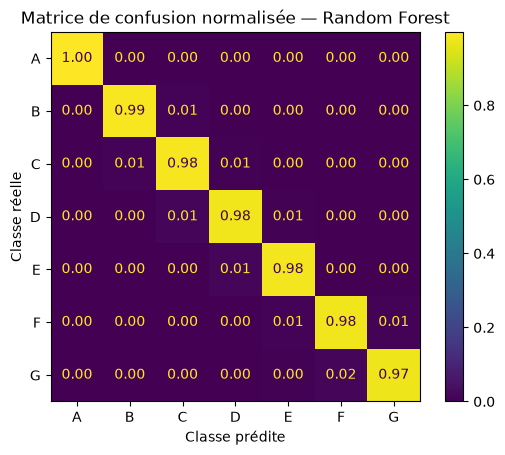


MATRICE DE CONFUSION — HISTGRADIENTBOOSTING


Classe prédite,A,B,C,D,E,F,G
Classe réelle,,,,,,,
A,24281,69,22,5,5,6,14
B,59,21599,625,71,13,4,0
C,17,931,29654,532,30,2,2
D,11,30,467,12537,182,3,0
E,7,1,28,178,5947,25,13
F,7,1,2,2,54,1842,13
G,1,0,25,1,13,26,643



MATRICE NORMALISÉE (%)


Classe prédite,A,B,C,D,E,F,G
Classe réelle,,,,,,,
A,99.50,0.28,0.09,0.02,0.02,0.02,0.06
B,0.26,96.55,2.79,0.32,0.06,0.02,0.00
C,0.05,2.99,95.14,1.71,0.10,0.01,0.01
D,0.08,0.23,3.53,94.76,1.38,0.02,0.00
E,0.11,0.02,0.45,2.87,95.93,0.40,0.21
F,0.36,0.05,0.10,0.10,2.81,95.89,0.68
G,0.14,0.00,3.53,0.14,1.83,3.67,90.69


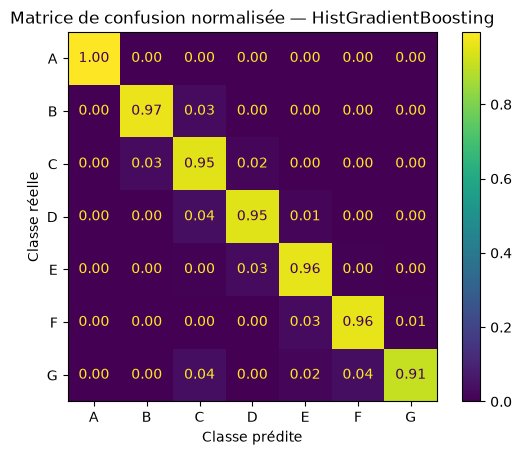


✅ Le Test final n'a pas été utilisé.


In [18]:
# =====================================================================
# 4.11 - Matrices de confusion
# =====================================================================

for model_name, model in selected_models_for_diagnostics.items():

    y_validation_pred = model.predict(
        X_validation_dev
    )

    matrix = confusion_matrix(
        y_validation_dev,
        y_validation_pred,
        labels=ADEME_LABELS,
    )

    matrix_normalized = confusion_matrix(
        y_validation_dev,
        y_validation_pred,
        labels=ADEME_LABELS,
        normalize="true",
    )

    print(
        f"\nMATRICE DE CONFUSION — {model_name.upper()}"
    )
    print("=" * 110)

    display(
        pd.DataFrame(
            matrix,
            index=pd.Index(
                ADEME_LABELS,
                name="Classe réelle",
            ),
            columns=pd.Index(
                ADEME_LABELS,
                name="Classe prédite",
            ),
        )
    )

    print(
        "\nMATRICE NORMALISÉE (%)"
    )

    display(
        pd.DataFrame(
            matrix_normalized * 100,
            index=pd.Index(
                ADEME_LABELS,
                name="Classe réelle",
            ),
            columns=pd.Index(
                ADEME_LABELS,
                name="Classe prédite",
            ),
        ).round(2)
    )

    ConfusionMatrixDisplay(
        confusion_matrix=matrix_normalized,
        display_labels=ADEME_LABELS,
    ).plot(
        values_format=".2f"
    )

    plt.title(
        f"Matrice de confusion normalisée — {model_name}"
    )
    plt.xlabel("Classe prédite")
    plt.ylabel("Classe réelle")
    plt.show()

print(
    "\n✅ Le Test final n'a pas été utilisé."
)

### 4.12 — Stratégie d'optimisation du Random Forest

Le Random Forest est le modèle ciblé par le pipeline d'industrialisation
existant.

L'optimisation utilise `RandomizedSearchCV` avec une validation croisée
stratifiée à trois folds sur **Train développement uniquement**.

Validation développement reste indépendante de la recherche et sera utilisée
ensuite pour comparer la configuration optimisée à la configuration de
référence.

Le Test final reste exclu.

In [19]:
# =====================================================================
# 4.12 - Définition de la stratégie d'optimisation
# =====================================================================

RF_PARAM_DISTRIBUTIONS = {
    "n_estimators": [
        100,
        200,
        300,
    ],
    "max_depth": [
        None,
        20,
        30,
        40,
    ],
    "min_samples_split": [
        2,
        5,
        10,
    ],
    "min_samples_leaf": [
        1,
        2,
        4,
    ],
    "max_features": [
        "sqrt",
        0.5,
        1.0,
    ],
}

RF_N_ITER = 10
CV_FOLDS = 3

rf_cv_strategy = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

total_rf_fits = (
    RF_N_ITER
    * rf_cv_strategy.get_n_splits()
)

tuning_strategy_df = pd.DataFrame(
    [
        {
            "modèle": "Random Forest",
            "configurations_testées": RF_N_ITER,
            "folds_cv": CV_FOLDS,
            "entraînements_cv": total_rf_fits,
            "métrique": "F1-macro",
            "jeu": "Train développement",
        }
    ]
)

print("=" * 110)
print("STRATÉGIE D'OPTIMISATION RANDOM FOREST")
print("=" * 110)

display(tuning_strategy_df)

print(
    f"\nTrain tuning         : {len(X_train_dev):,} observations"
)
print(
    f"Validation externe    : {len(X_validation_dev):,} observations"
)
print(
    f"Test final réservé    : {len(X_test):,} observations"
)

print(
    "\n✅ RandomizedSearchCV utilisera uniquement Train développement."
)

print(
    "✅ Validation développement reste externe au CV."
)

print(
    "✅ Le Test final reste totalement exclu."
)

STRATÉGIE D'OPTIMISATION RANDOM FOREST


,modèle,configurations_testées,folds_cv,entraînements_cv,métrique,jeu
0,Random Forest,10,3,30,F1-macro,Train développement



Train tuning         : 400,000 observations
Validation externe    : 100,000 observations
Test final réservé    : 2,151,637 observations

✅ RandomizedSearchCV utilisera uniquement Train développement.
✅ Validation développement reste externe au CV.
✅ Le Test final reste totalement exclu.


### 4.13 — Optimisation contrôlée du Random Forest

La recherche aléatoire teste un nombre limité de configurations afin de
maîtriser le coût computationnel.

Le `F1-macro` est utilisé comme score de sélection et la procédure reste
reproductible grâce au `random_state`.

In [20]:
# =====================================================================
# 4.13 - Optimisation contrôlée du Random Forest
# =====================================================================

random_forest_search_model = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

random_forest_search = RandomizedSearchCV(
    estimator=random_forest_search_model,
    param_distributions=RF_PARAM_DISTRIBUTIONS,
    n_iter=RF_N_ITER,
    scoring="f1_macro",
    cv=rf_cv_strategy,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=2,
    return_train_score=False,
    refit=True,
)

print("=" * 110)
print("OPTIMISATION CONTRÔLÉE DU RANDOM FOREST")
print("=" * 110)

print(
    f"\nObservations Train développement : {len(X_train_dev):,}"
)
print(
    f"Configurations testées            : {RF_N_ITER}"
)
print(
    f"Validation croisée                : {CV_FOLDS} folds"
)
print(
    f"Entraînements CV prévus           : {total_rf_fits}"
)
print(
    "Métrique principale              : F1-macro"
)

tuning_start_time = time.perf_counter()

random_forest_search.fit(
    X_train_dev,
    y_train_dev,
)

tuning_time_seconds = (
    time.perf_counter()
    - tuning_start_time
)

best_random_forest_model = (
    random_forest_search.best_estimator_
)

best_random_forest_params = (
    random_forest_search.best_params_
)

best_random_forest_cv_f1_macro = (
    random_forest_search.best_score_
)

random_forest_tuning_results_df = (
    pd.DataFrame(
        random_forest_search.cv_results_
    )
    [
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_fit_time",
            "params",
        ]
    ]
    .rename(
        columns={
            "rank_test_score": "Rang",
            "mean_test_score": "F1-macro moyen CV",
            "std_test_score": "Écart-type F1-macro",
            "mean_fit_time": "Temps moyen entraînement (s)",
            "params": "Hyperparamètres",
        }
    )
    .sort_values(by="Rang")
    .reset_index(drop=True)
)

print("\n" + "=" * 110)
print("RÉSULTATS DU TUNING")
print("=" * 110)

print(
    f"\nMeilleur F1-macro moyen CV : "
    f"{best_random_forest_cv_f1_macro:.4f}"
)

print(
    f"Temps total du tuning       : "
    f"{tuning_time_seconds:.2f} secondes"
)

print("\nMeilleurs hyperparamètres :")

for parameter, value in best_random_forest_params.items():
    print(f"  - {parameter}: {value}")

display(
    random_forest_tuning_results_df.round(
        {
            "F1-macro moyen CV": 4,
            "Écart-type F1-macro": 4,
            "Temps moyen entraînement (s)": 2,
        }
    )
)

rf_tuning_results_path = (
    reports_dir
    / "random_forest_classification_tuning_results.csv"
)

random_forest_tuning_results_df.to_csv(
    rf_tuning_results_path,
    index=False,
)

print(
    f"\n✅ Résultats sauvegardés : {rf_tuning_results_path}"
)

print(
    "✅ Le Test final n'a pas été utilisé."
)

OPTIMISATION CONTRÔLÉE DU RANDOM FOREST

Observations Train développement : 400,000
Configurations testées            : 10
Validation croisée                : 3 folds
Entraînements CV prévus           : 30
Métrique principale              : F1-macro
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END max_depth=20, max_features=0.5, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time= 1.0min
[CV] END max_depth=20, max_features=0.5, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time= 1.1min
[CV] END max_depth=20, max_features=0.5, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time= 1.1min
[CV] END max_depth=20, max_features=0.5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 1.1min
[CV] END max_depth=20, max_features=0.5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  56.6s
[CV] END max_depth=20, max_features=0.5, min_samples_leaf=1, min_samples_split=2, n_estimat

,Rang,F1-macro moyen CV,Écart-type F1-macro,Temps moyen entraînement (s),Hyperparamètres
0,1,0.9830,0.0007,60.04,"{'n_estimators': 100, 'min_samples_split': 2, ..."
1,2,0.9819,0.0009,125.79,"{'n_estimators': 200, 'min_samples_split': 10,..."
2,3,0.9812,0.0009,122.41,"{'n_estimators': 100, 'min_samples_split': 5, ..."
3,4,0.9803,0.0007,372.76,"{'n_estimators': 300, 'min_samples_split': 2, ..."
4,5,0.9795,0.0007,121.53,"{'n_estimators': 100, 'min_samples_split': 2, ..."
5,6,0.9794,0.0006,30.19,"{'n_estimators': 100, 'min_samples_split': 2, ..."
6,7,0.9790,0.0011,61.18,"{'n_estimators': 100, 'min_samples_split': 2, ..."
7,8,0.9789,0.0008,61.66,"{'n_estimators': 100, 'min_samples_split': 10,..."
8,9,0.9762,0.0004,76.64,"{'n_estimators': 300, 'min_samples_split': 5, ..."
9,10,0.9756,0.0005,32.16,"{'n_estimators': 100, 'min_samples_split': 2, ..."



✅ Résultats sauvegardés : /home/jmbandong/projects/ml-projects/vehicle-emissions-prediction-mlops/reports/tables/random_forest_classification_tuning_results.csv
✅ Le Test final n'a pas été utilisé.


### 4.14 — Comparaison du Random Forest de référence et du Random Forest optimisé

Les deux configurations sont évaluées sur exactement la même Validation
développement.

La décision est basée principalement sur le F1-macro Validation. Les résultats
sont générés dynamiquement.

In [21]:
# =====================================================================
# 4.14 - Comparaison Random Forest référence / optimisé
# =====================================================================

y_validation_rf_reference_pred = (
    random_forest_reference_model.predict(
        X_validation_dev
    )
)

y_validation_rf_optimized_pred = (
    best_random_forest_model.predict(
        X_validation_dev
    )
)


def summarize_predictions(
    model_name: str,
    y_true: pd.Series,
    y_pred: np.ndarray,
) -> dict:
    """Calcule les métriques de classification standard de scikit-learn."""

    return {
        "Modèle": model_name,
        "Accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_true,
            y_pred,
        ),
        "F1-macro": f1_score(
            y_true,
            y_pred,
            average="macro",
        ),
        "F1-weighted": f1_score(
            y_true,
            y_pred,
            average="weighted",
        ),
    }


rf_validation_comparison_df = pd.DataFrame(
    [
        summarize_predictions(
            "Random Forest de référence",
            y_validation_dev,
            y_validation_rf_reference_pred,
        ),
        summarize_predictions(
            "Random Forest optimisé",
            y_validation_dev,
            y_validation_rf_optimized_pred,
        ),
    ]
).sort_values(
    by="F1-macro",
    ascending=False,
).reset_index(drop=True)

reference_f1_macro = float(
    rf_validation_comparison_df.loc[
        rf_validation_comparison_df["Modèle"]
        == "Random Forest de référence",
        "F1-macro",
    ].iloc[0]
)

optimized_f1_macro = float(
    rf_validation_comparison_df.loc[
        rf_validation_comparison_df["Modèle"]
        == "Random Forest optimisé",
        "F1-macro",
    ].iloc[0]
)

f1_macro_gain = (
    optimized_f1_macro
    - reference_f1_macro
)

print("=" * 110)
print("COMPARAISON RANDOM FOREST RÉFÉRENCE / OPTIMISÉ")
print("=" * 110)

display(
    rf_validation_comparison_df.round(4)
)

print(
    f"\nF1-macro référence : {reference_f1_macro:.4f}"
)
print(
    f"F1-macro optimisé   : {optimized_f1_macro:.4f}"
)
print(
    f"Écart               : {f1_macro_gain:+.4f}"
)

if optimized_f1_macro >= reference_f1_macro:
    selected_random_forest_model = best_random_forest_model
    selected_random_forest_params = best_random_forest_params.copy()
    selected_configuration_name = "Random Forest optimisé"
else:
    selected_random_forest_model = random_forest_reference_model
    selected_random_forest_params = {
        "n_estimators": random_forest_reference_model.n_estimators,
        "max_depth": random_forest_reference_model.max_depth,
        "min_samples_split": random_forest_reference_model.min_samples_split,
        "min_samples_leaf": random_forest_reference_model.min_samples_leaf,
        "max_features": random_forest_reference_model.max_features,
    }
    selected_configuration_name = "Random Forest de référence"

print(
    f"\nConfiguration retenue : {selected_configuration_name}"
)

print(
    "✅ La sélection repose exclusivement sur Validation développement."
)

print(
    "✅ Le Test final reste totalement isolé."
)

COMPARAISON RANDOM FOREST RÉFÉRENCE / OPTIMISÉ


,Modèle,Accuracy,Balanced Accuracy,F1-macro,F1-weighted
0,Random Forest optimisé,0.9888,0.9842,0.9847,0.9888
1,Random Forest de référence,0.9877,0.9830,0.9839,0.9877



F1-macro référence : 0.9839
F1-macro optimisé   : 0.9847
Écart               : +0.0007

Configuration retenue : Random Forest optimisé
✅ La sélection repose exclusivement sur Validation développement.
✅ Le Test final reste totalement isolé.


### 4.15 — Préparation du candidat final pour l'industrialisation

La configuration Random Forest retenue est préparée pour le futur entraînement
FULL.

Le notebook n'effectue pas encore cet entraînement complet. Il prépare les
hyperparamètres et la structure nécessaires au script industrialisé.

In [22]:
# =====================================================================
# 4.15 - Préparation du candidat final
# =====================================================================

final_classification_params = {
    **selected_random_forest_params,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

final_random_forest_classifier = RandomForestClassifier(
    **final_classification_params
)

final_classification_summary_df = pd.DataFrame(
    {
        "élément": [
            "Modèle candidat",
            "Configuration sélectionnée",
            "Cible",
            "Train FULL disponible",
            "Test final réservé",
            "Nombre de variables",
            "Métrique principale",
        ],
        "valeur": [
            "RandomForestClassifier",
            selected_configuration_name,
            "co2_wltp_g_km → classes A à G",
            f"{len(X_train):,} observations",
            f"{len(X_test):,} observations",
            X_train.shape[1],
            "F1-macro",
        ],
    }
)

print("=" * 110)
print("PRÉPARATION DU CANDIDAT FINAL")
print("=" * 110)

display(final_classification_summary_df)

print("\nHYPERPARAMÈTRES À INDUSTRIALISER")

for parameter, value in final_classification_params.items():
    print(f"  - {parameter}: {value}")

print(
    "\n✅ Aucun entraînement FULL n'a été lancé dans le notebook."
)

print(
    "✅ Le Test final n'a toujours pas été utilisé."
)

PRÉPARATION DU CANDIDAT FINAL


,élément,valeur
0,Modèle candidat,RandomForestClassifier
1,Configuration sélectionnée,Random Forest optimisé
2,Cible,co2_wltp_g_km → classes A à G
3,Train FULL disponible,"8,606,547 observations"
4,Test final réservé,"2,151,637 observations"
5,Nombre de variables,35
6,Métrique principale,F1-macro



HYPERPARAMÈTRES À INDUSTRIALISER
  - n_estimators: 100
  - min_samples_split: 2
  - min_samples_leaf: 1
  - max_features: 0.5
  - max_depth: 20
  - random_state: 42
  - n_jobs: -1

✅ Aucun entraînement FULL n'a été lancé dans le notebook.
✅ Le Test final n'a toujours pas été utilisé.


### 4.16 — Évaluation finale du candidat sélectionné

Le modèle a maintenant été sélectionné sans utiliser le Test final.

À cette étape seulement, les seuils fixes A à G sont appliqués à `y_test` afin
de construire `y_test_class`.

Le candidat sélectionné, déjà entraîné sur Train développement, est ensuite
évalué une seule fois sur le Test final.

Cette évaluation ne sert pas à modifier les hyperparamètres.

ÉVALUATION FINALE DU CANDIDAT SÉLECTIONNÉ

Configuration : Random Forest optimisé
Observations Test final : 2,151,637


,Modèle,Observations,Accuracy,Balanced Accuracy,F1-macro,F1-weighted
0,Random Forest optimisé,2151637,0.989,0.9847,0.985,0.989



PERFORMANCES FINALES PAR CLASSE


,precision,recall,f1-score,support
Classe ADEME,,,,
A,0.9986,0.9988,0.9987,524232.0
B,0.9882,0.9904,0.9893,482347.0
C,0.9888,0.9862,0.9875,670960.0
D,0.9791,0.9811,0.9801,284593.0
E,0.9794,0.9821,0.9808,133221.0
F,0.9830,0.9744,0.9787,41154.0
G,0.9802,0.9798,0.9800,15130.0


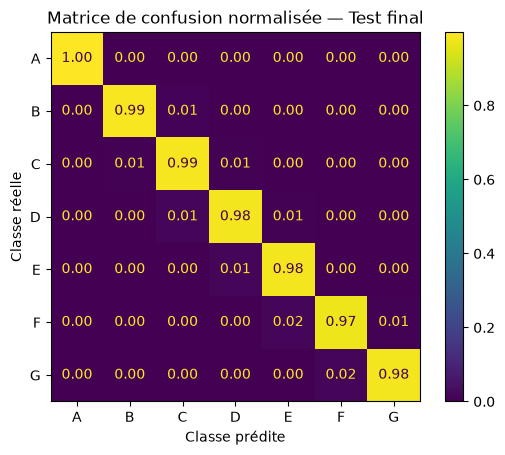


✅ Le Test final a été utilisé uniquement après la sélection du candidat.
✅ Aucun hyperparamètre ne doit être modifié à partir de ce résultat.


In [23]:
# =====================================================================
# 4.16 - Évaluation finale sur le Test final
# =====================================================================

# ---------------------------------------------------------------------
# 1. Construction de y_test_class uniquement maintenant
# ---------------------------------------------------------------------

y_test_class = pd.cut(
    y_test,
    bins=ADEME_BINS,
    labels=ADEME_LABELS,
    include_lowest=True,
)

if y_test_class.isna().any():
    raise ValueError(
        "Certaines observations du Test final ne sont pas classées."
    )


# ---------------------------------------------------------------------
# 2. Prédiction finale
# ---------------------------------------------------------------------

print("=" * 110)
print("ÉVALUATION FINALE DU CANDIDAT SÉLECTIONNÉ")
print("=" * 110)

print(
    f"\nConfiguration : {selected_configuration_name}"
)

print(
    f"Observations Test final : {len(X_test):,}"
)

y_test_final_pred = (
    selected_random_forest_model.predict(
        X_test
    )
)

final_test_metrics = {
    "accuracy": float(
        accuracy_score(
            y_test_class,
            y_test_final_pred,
        )
    ),
    "balanced_accuracy": float(
        balanced_accuracy_score(
            y_test_class,
            y_test_final_pred,
        )
    ),
    "f1_macro": float(
        f1_score(
            y_test_class,
            y_test_final_pred,
            average="macro",
        )
    ),
    "f1_weighted": float(
        f1_score(
            y_test_class,
            y_test_final_pred,
            average="weighted",
        )
    ),
}

final_test_evaluation_df = pd.DataFrame(
    [
        {
            "Modèle": selected_configuration_name,
            "Observations": len(X_test),
            "Accuracy": final_test_metrics["accuracy"],
            "Balanced Accuracy": final_test_metrics[
                "balanced_accuracy"
            ],
            "F1-macro": final_test_metrics["f1_macro"],
            "F1-weighted": final_test_metrics[
                "f1_weighted"
            ],
        }
    ]
)

display(
    final_test_evaluation_df.round(4)
)


# ---------------------------------------------------------------------
# 3. Rapport par classe
# ---------------------------------------------------------------------

final_classification_report = classification_report(
    y_test_class,
    y_test_final_pred,
    labels=ADEME_LABELS,
    output_dict=True,
    zero_division=0,
)

final_classification_report_df = (
    pd.DataFrame(final_classification_report)
    .T
    .loc[
        ADEME_LABELS,
        [
            "precision",
            "recall",
            "f1-score",
            "support",
        ],
    ]
)

final_classification_report_df.index.name = "Classe ADEME"

print("\nPERFORMANCES FINALES PAR CLASSE")
display(
    final_classification_report_df.round(4)
)


# ---------------------------------------------------------------------
# 4. Matrice de confusion finale
# ---------------------------------------------------------------------

final_confusion_matrix_normalized = confusion_matrix(
    y_test_class,
    y_test_final_pred,
    labels=ADEME_LABELS,
    normalize="true",
)

ConfusionMatrixDisplay(
    confusion_matrix=final_confusion_matrix_normalized,
    display_labels=ADEME_LABELS,
).plot(
    values_format=".2f"
)

plt.title(
    "Matrice de confusion normalisée — Test final"
)
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

print(
    "\n✅ Le Test final a été utilisé uniquement après la sélection du candidat."
)

print(
    "✅ Aucun hyperparamètre ne doit être modifié à partir de ce résultat."
)

### 4.17 — Sauvegarde des rapports et des métadonnées de sélection

Les résultats utiles à la traçabilité sont sauvegardés dans `reports/tables/`.

Les métadonnées destinées au script industrialisé sont sauvegardées dans :

`models/metadata/random_forest_classification_metadata.json`

Les valeurs expérimentales sont écrites dynamiquement à partir de l'exécution
courante du notebook.

In [24]:
# =====================================================================
# 4.17 - Sauvegarde des rapports et métadonnées de classification
# =====================================================================

# ---------------------------------------------------------------------
# 1. Sauvegarde des rapports CSV
# ---------------------------------------------------------------------

rf_optimized_validation_path = (
    reports_dir
    / "random_forest_classification_optimized_validation.csv"
)

classification_final_test_path = (
    reports_dir
    / "classification_final_test_evaluation.csv"
)

classification_final_per_class_path = (
    reports_dir
    / "classification_final_test_per_class.csv"
)

rf_validation_comparison_df.to_csv(
    rf_optimized_validation_path,
    index=False,
)

final_test_evaluation_df.to_csv(
    classification_final_test_path,
    index=False,
)

final_classification_report_df.to_csv(
    classification_final_per_class_path,
)


# ---------------------------------------------------------------------
# 2. Métadonnées du modèle sélectionné
# ---------------------------------------------------------------------

classification_metadata_path = (
    metadata_dir
    / "random_forest_classification_metadata.json"
)

serialized_bins = [
    (
        "-inf"
        if value == float("-inf")
        else "inf"
        if value == float("inf")
        else value
    )
    for value in ADEME_BINS
]

classification_metadata = {
    "problem_type": "multiclass_classification",
    "model_selected": "RandomForestClassifier",
    "model_name": "random_forest_classifier",
    "target_original": TARGET_COLUMN,
    "target_classification": "co2_emission_class",
    "classes": ADEME_LABELS,
    "class_intervals_g_co2_km": CLASS_INTERVALS,
    "class_business_labels": CLASS_BUSINESS_LABELS,
    "classification_bins": serialized_bins,
    "selection_metric": "f1_macro",
    "selected_configuration": selected_configuration_name,
    "best_random_forest_params": {
        key: (
            value.item()
            if hasattr(value, "item")
            else value
        )
        for key, value in final_classification_params.items()
    },
    "features": X_train.columns.tolist(),
    "feature_count": int(X_train.shape[1]),
    "excluded_features": [
        "manufacturer_make"
    ],
    "train_full": {
        "observations": int(len(X_train)),
        "features": int(X_train.shape[1]),
    },
    "development": {
        "observations": int(len(X_development)),
        "train_observations": int(len(X_train_dev)),
        "validation_observations": int(len(X_validation_dev)),
    },
    "validation": {
        "f1_macro_reference": float(reference_f1_macro),
        "f1_macro_optimized": float(optimized_f1_macro),
        "f1_macro_gain": float(f1_macro_gain),
        "best_cv_f1_macro": float(best_random_forest_cv_f1_macro),
    },
    "test_final": {
        "observations": int(len(X_test)),
        "features": int(X_test.shape[1]),
        **final_test_metrics,
    },
}

with classification_metadata_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        classification_metadata,
        file,
        indent=4,
        ensure_ascii=False,
    )


# ---------------------------------------------------------------------
# 3. Rapport
# ---------------------------------------------------------------------

print("=" * 110)
print("SAUVEGARDE DES RAPPORTS ET MÉTADONNÉES")
print("=" * 110)

print(
    f"\nComparaison modèles : {classification_comparison_path}"
)
print(
    f"Tuning Random Forest : {rf_tuning_results_path}"
)
print(
    f"Validation RF         : {rf_optimized_validation_path}"
)
print(
    f"Test final            : {classification_final_test_path}"
)
print(
    f"Rapport par classe    : {classification_final_per_class_path}"
)
print(
    f"Métadonnées           : {classification_metadata_path}"
)

print(
    "\n✅ Rapports et métadonnées sauvegardés."
)

SAUVEGARDE DES RAPPORTS ET MÉTADONNÉES

Comparaison modèles : /home/jmbandong/projects/ml-projects/vehicle-emissions-prediction-mlops/reports/tables/classification_model_comparison.csv
Tuning Random Forest : /home/jmbandong/projects/ml-projects/vehicle-emissions-prediction-mlops/reports/tables/random_forest_classification_tuning_results.csv
Validation RF         : /home/jmbandong/projects/ml-projects/vehicle-emissions-prediction-mlops/reports/tables/random_forest_classification_optimized_validation.csv
Test final            : /home/jmbandong/projects/ml-projects/vehicle-emissions-prediction-mlops/reports/tables/classification_final_test_evaluation.csv
Rapport par classe    : /home/jmbandong/projects/ml-projects/vehicle-emissions-prediction-mlops/reports/tables/classification_final_test_per_class.csv
Métadonnées           : /home/jmbandong/projects/ml-projects/vehicle-emissions-prediction-mlops/models/metadata/random_forest_classification_metadata.json

✅ Rapports et métadonnées sauvega

### 4.18 — Contrôle des métadonnées du modèle retenu

Le fichier JSON est rechargé et contrôlé avant son utilisation par le script
d'entraînement industrialisé.

Le contrôle porte notamment sur :

- la classe du modèle ;
- les hyperparamètres ;
- les classes et seuils ;
- le nombre et l'ordre des variables ;
- l'exclusion de `manufacturer_make` ;
- les métriques du Test final.

In [25]:
# =====================================================================
# 4.18 - Contrôle des métadonnées sauvegardées
# =====================================================================

with classification_metadata_path.open(
    "r",
    encoding="utf-8",
) as file:
    saved_classification_metadata = json.load(file)

required_metadata_keys = [
    "problem_type",
    "model_selected",
    "model_name",
    "target_original",
    "target_classification",
    "classes",
    "class_intervals_g_co2_km",
    "class_business_labels",
    "classification_bins",
    "selection_metric",
    "best_random_forest_params",
    "features",
    "feature_count",
    "excluded_features",
    "train_full",
    "development",
    "validation",
    "test_final",
]

missing_metadata_keys = [
    key
    for key in required_metadata_keys
    if key not in saved_classification_metadata
]

metadata_checks = {
    "Toutes les clés requises présentes":
        not missing_metadata_keys,

    "Modèle conforme":
        saved_classification_metadata.get(
            "model_selected"
        ) == "RandomForestClassifier",

    "Cible conforme":
        saved_classification_metadata.get(
            "target_original"
        ) == TARGET_COLUMN,

    "Classes A à G conformes":
        saved_classification_metadata.get(
            "classes"
        ) == ADEME_LABELS,

    "Nombre de variables conforme":
        saved_classification_metadata.get(
            "feature_count"
        ) == X_train.shape[1],

    "Ordre des variables conforme":
        saved_classification_metadata.get(
            "features"
        ) == X_train.columns.tolist(),

    "manufacturer_make exclue":
        "manufacturer_make"
        in saved_classification_metadata.get(
            "excluded_features",
            [],
        )
        and all(
            "manufacturer_make" not in column.lower()
            for column in saved_classification_metadata.get(
                "features",
                [],
            )
        ),

    "Hyperparamètres présents":
        bool(
            saved_classification_metadata.get(
                "best_random_forest_params"
            )
        ),

    "Métrique finale F1-macro présente":
        "f1_macro"
        in saved_classification_metadata.get(
            "test_final",
            {},
        ),
}

failed_metadata_checks = [
    name
    for name, result in metadata_checks.items()
    if not result
]

print("=" * 110)
print("CONTRÔLE DES MÉTADONNÉES DE CLASSIFICATION")
print("=" * 110)

for name, result in metadata_checks.items():
    print(f"{'✅' if result else '❌'} {name}")

if failed_metadata_checks:
    raise ValueError(
        "Contrôle des métadonnées échoué : "
        + ", ".join(failed_metadata_checks)
    )

print(
    f"\nFichier contrôlé : {classification_metadata_path}"
)

print(
    f"Variables         : "
    f"{saved_classification_metadata['feature_count']}"
)

print(
    f"Classes           : "
    f"{', '.join(saved_classification_metadata['classes'])}"
)

print(
    "\n✅ Les métadonnées sont prêtes pour le script industrialisé."
)

CONTRÔLE DES MÉTADONNÉES DE CLASSIFICATION
✅ Toutes les clés requises présentes
✅ Modèle conforme
✅ Cible conforme
✅ Classes A à G conformes
✅ Nombre de variables conforme
✅ Ordre des variables conforme
✅ manufacturer_make exclue
✅ Hyperparamètres présents
✅ Métrique finale F1-macro présente

Fichier contrôlé : /home/jmbandong/projects/ml-projects/vehicle-emissions-prediction-mlops/models/metadata/random_forest_classification_metadata.json
Variables         : 35
Classes           : A, B, C, D, E, F, G

✅ Les métadonnées sont prêtes pour le script industrialisé.


## 5. Validation finale du notebook et préparation à l'industrialisation

Cette dernière étape vérifie la présence des principaux rapports et du fichier
de métadonnées.

Le notebook s'arrête ici : le réentraînement du Random Forest sur le Train FULL
sera exécuté par `src/vehicle_emissions/training/train_classification_model.py`
puis géré par DVC.

In [ ]:
# =====================================================================
# 5 - Validation finale du notebook
# =====================================================================

expected_output_files = [
    classification_comparison_path,
    rf_tuning_results_path,
    rf_optimized_validation_path,
    classification_final_test_path,
    classification_final_per_class_path,
    classification_metadata_path,
]

output_checks = {
    path.name: path.is_file()
    for path in expected_output_files
}

print("=" * 110)
print("VALIDATION FINALE DU NOTEBOOK 05")
print("=" * 110)

for filename, exists in output_checks.items():
    print(
        f"{'✅' if exists else '❌'} {filename}"
    )

if not all(output_checks.values()):
    missing_outputs = [
        filename
        for filename, exists in output_checks.items()
        if not exists
    ]

    raise FileNotFoundError(
        "Sortie(s) attendue(s) manquante(s) : "
        + ", ".join(missing_outputs)
    )

print(
    f"\n✅ Nombre de variables finales : {X_train.shape[1]}"
)

print(
    "✅ manufacturer_make est exclue du modèle."
)

print(
    "✅ Le Test final a été utilisé uniquement après sélection du candidat."
)

print(
    "✅ Les hyperparamètres et métadonnées sont prêts pour "
    "l'entraînement FULL industrialisé."
)

print(
    "\n✅ Notebook 05 terminé avec succès."
)

VALIDATION FINALE DU NOTEBOOK 05
✅ classification_model_comparison.csv
✅ random_forest_classification_tuning_results.csv
✅ random_forest_classification_optimized_validation.csv
✅ classification_final_test_evaluation.csv
✅ classification_final_test_per_class.csv
✅ random_forest_classification_metadata.json

✅ Nombre de variables finales : 35
✅ manufacturer_make est exclue du modèle.
✅ Le Test final a été utilisé uniquement après sélection du candidat.
✅ Les hyperparamètres et métadonnées sont prêts pour l'entraînement FULL industrialisé.

✅ Notebook 05 terminé avec succès.


: 